In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("import All modules.")

import All modules.


In [14]:
df = pd.read_csv(r"C:\Users\AlokVerma\Desktop\ML DATA\50_Startups.csv")
df.head(5)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
df.value_counts().sum()

np.int64(50)

In [6]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [7]:
df.head(2)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.2,136897.80,471784.10,New York,192261.83
1,162597.7,151377.59,443898.53,California,191792.06


In [15]:
X = df.iloc[:,0].values
y = df.iloc[:,-1].values

In [16]:
type(X)

numpy.ndarray

In [17]:
from sklearn.model_selection import  train_test_split
from sklearn.linear_model import LinearRegression

In [18]:
X_train, X_test , y_train,y_test = train_test_split(X,y,test_size=0.2)

In [19]:
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
sc = StandardScaler()

In [22]:
X_test_sc = sc.fit_transform(X_test)
X_train_sc = sc.fit_transform(X_train)

In [24]:
X_test

array([[130298.13],
       [119943.24],
       [144372.41],
       [ 23640.93],
       [ 76253.86],
       [  1000.23],
       [ 86419.7 ],
       [ 63408.86],
       [ 91749.16],
       [ 55493.95]])

In [25]:
X_test_sc

array([[ 1.17871783],
       [ 0.93958237],
       [ 1.50374874],
       [-1.28441969],
       [-0.06937859],
       [-1.80728319],
       [ 0.16539096],
       [-0.36602055],
       [ 0.28846931],
       [-0.5488072 ]])

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model = LinearRegression()

In [28]:
model.fit(X_train_sc,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred = model.predict(X_test_sc)

In [31]:
y_pred

array([158027.83342496, 148452.57967343, 171042.43834786,  59401.0247937 ,
       108052.64304957,  38464.97934925, 117453.08067831,  96174.76366713,
       122381.27710132,  88855.77991448])

In [32]:
 from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [36]:
model.score(X_train_sc,y_train)

0.9490389586680438

In [37]:
model.score(X_test_sc,y_test)

0.8767290078398158

In [41]:
mae = mean_absolute_error(y_test,y_pred)

In [42]:
mae

9535.028619677034

In [43]:
mse = mean_squared_error(y_test,y_pred)
mse

144843429.0310544

In [50]:
r2 = r2_score(y_test, y_pred)
print(r2)

0.8767290078398158


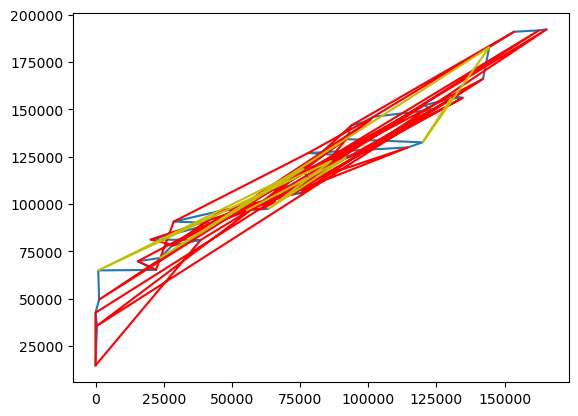

In [53]:
plt.plot(X,y)
plt.plot(X_train,y_train,color = "r")
plt.plot(X_test,y_test,color = 'y')

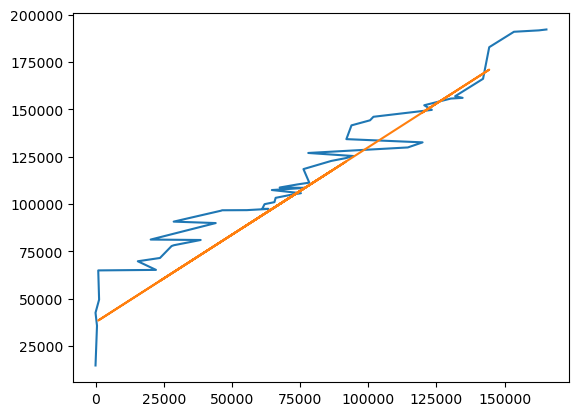

In [56]:
plt.plot(X,y)
plt.plot(X_test,y_pred)